EDA


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

Initial Data Analysis on Just KT1 Dataset

In [23]:
# Load Parquet file
file_path = r"C:\Users\missm\OneDrive\Documents\Capstone_Project_Strickland\CapstoneProject_LearningPatterns\KT1_cleaned_sample.parquet"
df = pd.read_parquet(file_path)

# Quick view
df.head(10)

,timestamp,solving_id,question_id,user_answer,elapsed_time,user_id
0,2019-08-06 12:56:30.868,1,q5012,b,38000,u1
1,2019-08-06 12:57:01.062,2,q4706,c,24000,u1
2,2019-08-06 12:58:13.432,3,q4366,b,68000,u1
3,2019-08-06 12:58:59.668,4,q4829,a,42000,u1
4,2019-08-06 13:00:01.774,5,q6528,b,59000,u1
5,2019-08-06 13:01:03.370,6,q4793,a,58000,u1
6,2019-08-06 13:01:41.746,7,q6488,a,35000,u1
7,2019-08-06 13:11:41.361,8,q356,b,23000,u1
8,2019-08-06 13:12:51.393,9,q1382,c,22000,u1
9,2019-08-06 13:14:00.758,10,q830,b,25000,u1


In [24]:
### Initial Inspection

# Shape of the dataset
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# Data types and nulls
df.info()

# Missing values
df.isnull().sum()

# Summary statistics
df.describe(include='all')


Rows: 1402362, Columns: 6
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1402362 entries, 0 to 1402361
Data columns (total 6 columns):
 #   Column        Non-Null Count    Dtype         
---  ------        --------------    -----         
 0   timestamp     1402362 non-null  datetime64[ns]
 1   solving_id    1402362 non-null  int64         
 2   question_id   1402362 non-null  object        
 3   user_answer   1402269 non-null  object        
 4   elapsed_time  1402362 non-null  int64         
 5   user_id       1402362 non-null  object        
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 64.2+ MB


,timestamp,solving_id,question_id,user_answer,elapsed_time,user_id
count,1402362,1.402362e+06,1402362,1402269,1.402362e+06,1402362
unique,NaN,NaN,11859,4,NaN,5000
top,NaN,NaN,q8074,b,NaN,u102446
freq,NaN,NaN,4705,397127,NaN,26255
mean,2018-10-15 20:29:37.980044800,1.570615e+03,NaN,NaN,2.625437e+04,NaN
min,2017-04-26 08:38:28.792000,1.000000e+00,NaN,NaN,0.000000e+00,NaN
25%,2018-02-11 05:33:58.399249920,1.770000e+02,NaN,NaN,1.600000e+04,NaN
50%,2018-08-19 05:26:50.802500096,6.400000e+02,NaN,NaN,2.100000e+04,NaN
75%,2019-07-14 14:38:20.196000,1.792000e+03,NaN,NaN,3.000000e+04,NaN
max,2019-12-02 14:25:25.437000,2.054700e+04,NaN,NaN,1.790000e+06,NaN


In [25]:
print(df.columns.tolist())


['timestamp', 'solving_id', 'question_id', 'user_answer', 'elapsed_time', 'user_id']


Visual Exploration

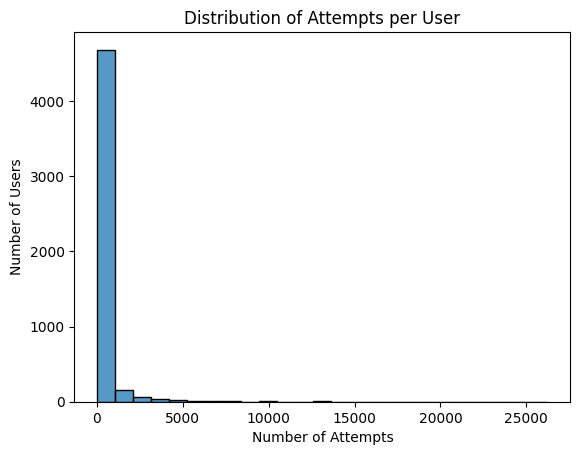

In [26]:
# Distribution of attempts per user
user_counts = df['user_id'].value_counts()
sns.histplot(user_counts, bins=25)
plt.title('Distribution of Attempts per User')
plt.xlabel('Number of Attempts')
plt.ylabel('Number of Users')
plt.show()

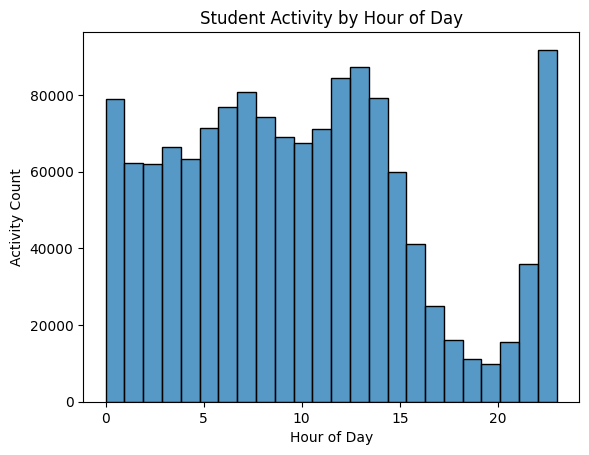

In [27]:
### Timestamp Analysis
# Convert if needed
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Extract hour of day
df['hour'] = df['timestamp'].dt.hour
sns.histplot(df['hour'], bins=24)
plt.title('Student Activity by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Activity Count')
plt.show()



Exploratory Data Analysis on All EdNet Datasets
[text](https://github.com/riiid/ednet)


In [28]:
# Step 1: Load Data
student_features = pd.read_parquet("student_behavior_features.parquet")
student_features = student_features.fillna(0)


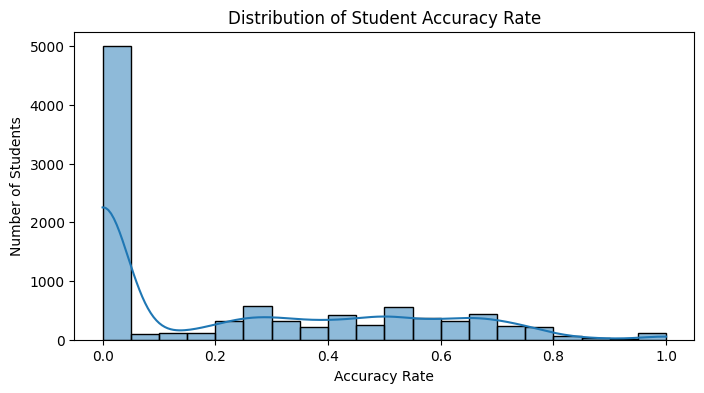

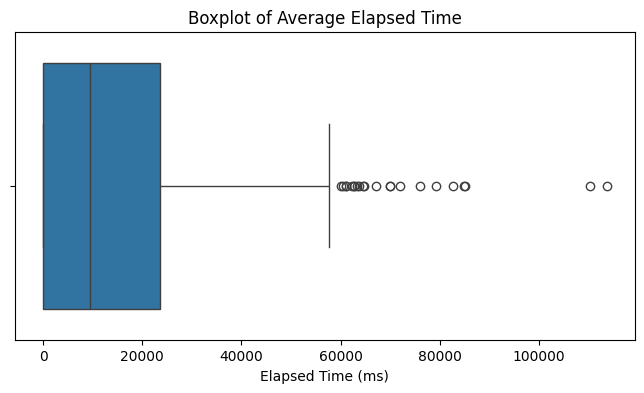

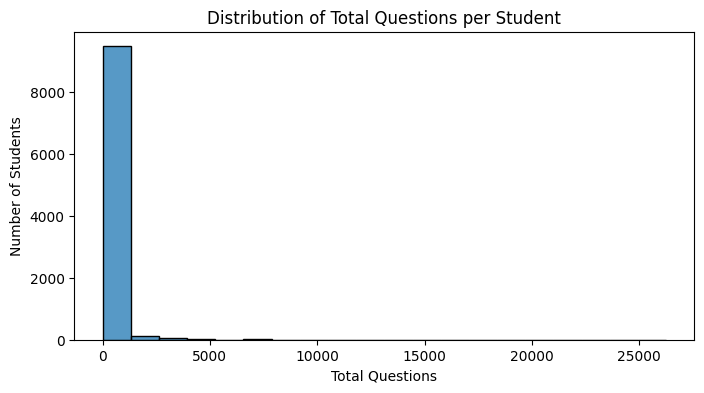

In [ ]:
# Step 2: Visualizations
plt.figure(figsize=(8, 4))
sns.histplot(student_features["accuracy_rate"], bins=20, kde=True)
plt.title("Distribution of Student Accuracy Rate")
plt.xlabel("Accuracy Rate")
plt.ylabel("Number of Students")
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(x=student_features["avg_elapsed_time"])
plt.title("Boxplot of Average Elapsed Time")
plt.xlabel("Elapsed Time (ms)")
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(student_features["total_questions"], bins=20)
plt.title("Distribution of Total Questions per Student")
plt.xlabel("Total Questions")
plt.ylabel("Number of Students")
plt.show()


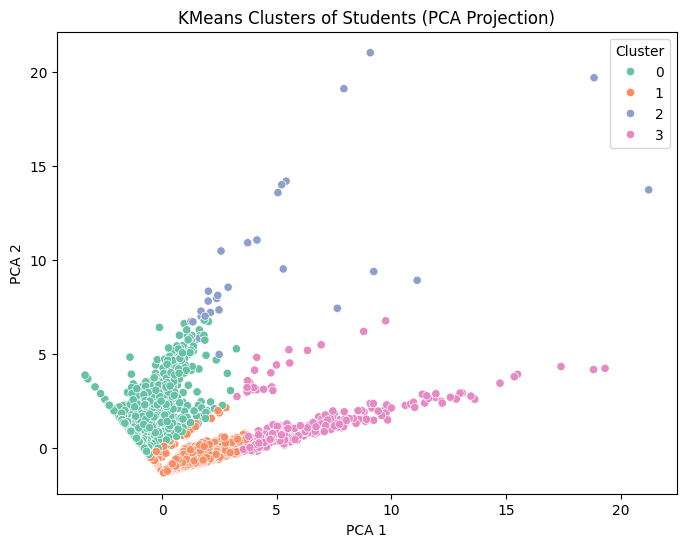


Cluster Summary:

                total_questions  avg_elapsed_time  accuracy_rate  \
kmeans_cluster                                                     
0                    221.909465      25270.810547       0.476252   
1                      4.556196        912.867615       0.008921   
2                  10315.285714      26820.498047       0.590244   
3                    275.078189       2567.475342       0.004686   

                 num_actions  active_days  
kmeans_cluster                             
0                 195.296296    59.611219  
1                3420.073487    56.252161  
2               16847.571429   375.928571  
3               54026.098765   199.534979  


In [29]:
# Step 3: Prepare Features for Clustering
features = student_features[[
    "total_questions", "avg_elapsed_time", "accuracy_rate",
    "num_responses", "num_actions", "active_days"
]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# Step 4: KMeans Clustering
kmeans = KMeans(n_clusters=4, random_state=42)
student_features["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

# Step 5: DBSCAN Clustering
# dbscan = DBSCAN(eps=1.5, min_samples=5)
# student_features["dbscan_cluster"] = dbscan.fit_predict(X_scaled)

# Step 6: PCA for Visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
student_features["pca1"] = X_pca[:, 0]
student_features["pca2"] = X_pca[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=student_features, x="pca1", y="pca2", hue="kmeans_cluster", palette="Set2")
plt.title("KMeans Clusters of Students (PCA Projection)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title="Cluster")
plt.show()

# Step 7: Interpret Cluster Characteristics
cluster_summary = student_features.groupby("kmeans_cluster")[[
    "total_questions", "avg_elapsed_time", "accuracy_rate", "num_actions", "active_days"
]].mean()

print("\nCluster Summary:\n")
print(cluster_summary)

# Optional: Save results
student_features.to_parquet("clustered_student_features.parquet")

C:\Users\missm\AppData\Local\Temp\ipykernel_13508\2985495787.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=student_features, x="kmeans_cluster", y="accuracy_rate", ci=None)


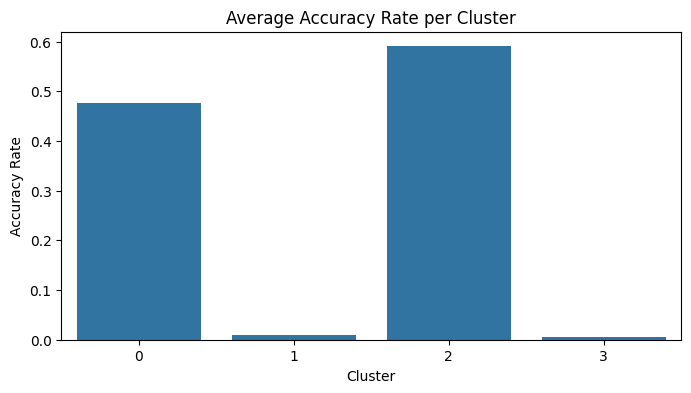

In [30]:
# 1. Average accuracy per cluster
plt.figure(figsize=(8, 4))
sns.barplot(data=student_features, x="kmeans_cluster", y="accuracy_rate", ci=None)
plt.title("Average Accuracy Rate per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Accuracy Rate")
plt.show()

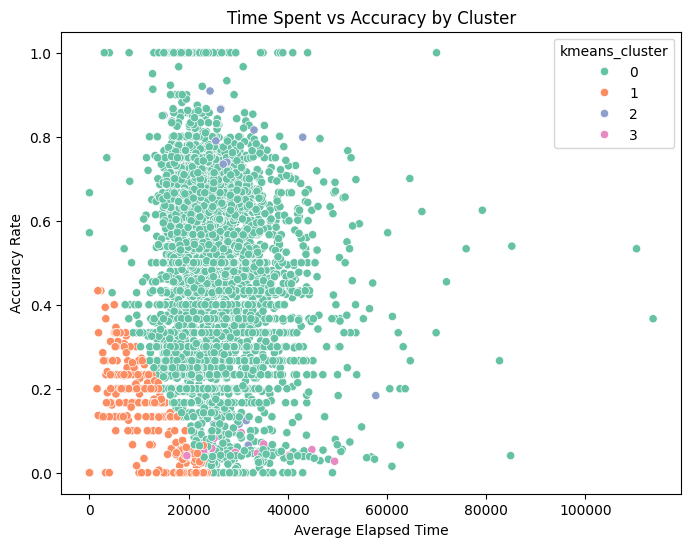

In [31]:
# 2. Time spent vs. accuracy colored by cluster
plt.figure(figsize=(8, 6))
sns.scatterplot(data=student_features, x="avg_elapsed_time", y="accuracy_rate", hue="kmeans_cluster", palette="Set2")
plt.title("Time Spent vs Accuracy by Cluster")
plt.xlabel("Average Elapsed Time")
plt.ylabel("Accuracy Rate")
plt.show()

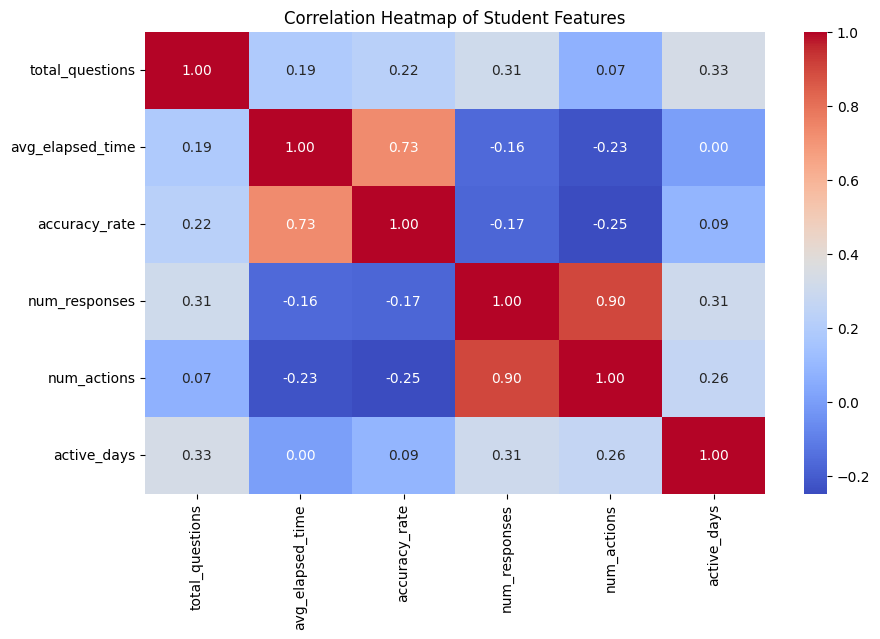

In [32]:
# 3. Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(student_features[[
    "total_questions", "avg_elapsed_time", "accuracy_rate",
    "num_responses", "num_actions", "active_days"
]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Student Features")
plt.show()

In [34]:
# 5. Flag struggling students
struggling_students = student_features[
    (student_features["accuracy_rate"] < 0.4) & (student_features["total_questions"] < 20)
]

print("\nStruggling Students (low accuracy and low activity):")
print(struggling_students[["accuracy_rate", "total_questions", "kmeans_cluster"]])



Struggling Students (low accuracy and low activity):
         accuracy_rate  total_questions  kmeans_cluster
user_id                                                
u10           0.310345               16               0
u100000            0.0                1               0
u100024           0.25                4               0
u100030           0.25                4               0
u100036           0.25                4               0
...                ...              ...             ...
u1834              0.0                0               1
u18340             0.0                0               1
u18341             0.0                0               1
u183419            0.0                0               1
u18342             0.0                0               1

[5267 rows x 3 columns]


In [35]:
# Save results
student_features.to_parquet("clustered_student_features.parquet")


In [38]:
path = r"C:\Users\missm\OneDrive\Documents\Capstone_Project_Strickland\CapstoneProject_LearningPatterns\clustered_student_features.parquet"
with open(path, "rb") as f:
    header = f.read(4)
    f.seek(-4, 2)
    footer = f.read(4)
print("header:", header, "footer:", footer)


header: b'PAR1' footer: b'PAR1'


In [39]:
# View parquet column titles


# Load just the metadata, not the full file
df_cluster = pd.read_parquet(r"C:\Users\missm\OneDrive\Documents\Capstone_Project_Strickland\CapstoneProject_LearningPatterns\clustered_student_features.parquet"
                     )

# Print column names
print(df_cluster.columns.tolist())


['total_questions', 'avg_elapsed_time', 'accuracy_rate', 'num_responses', 'num_actions', 'first_timestamp', 'last_timestamp', 'active_days', 'kmeans_cluster', 'pca1', 'pca2']


In [41]:
# Compare clusters by tanle
from IPython.display import display
display(round(cluster_summary,1))


,total_questions,avg_elapsed_time,accuracy_rate,num_actions,active_days
kmeans_cluster,,,,,
0,221.9,25270.800781,0.5,195.3,59.6
1,4.6,912.900024,0.0,3420.1,56.3
2,10315.3,26820.5,0.6,16847.6,375.9
3,275.1,2567.5,0.0,54026.1,199.5


print(cluster_summary.to_markdown(index=False))

Cluster 0

Attempt count ~ 222, avg time ~ 25 s, accuracy ≈ 50%, actions ~ 195, active days ~ 60
→ Moderate learners: they answer a few hundred questions over two months, take ~25 s each, get about half correct, and do a couple of actions per question.

Cluster 1

Very few questions (~ 5), very fast (~ 0.9 s), 0% accuracy, lots of actions (~ 3 k), ~ 56 days
→ “Browsers”: they open many question screens (lots of UI actions) but rarely submit answers (accuracy=0), and only a handful of attempts.

Cluster 2

Extremely active (~ 10 k questions), slow (~ 27 s), 60% accuracy, ~ 17 k actions, > 1 year active (376 days!)
→ Power users: they’ve practiced relentlessly, take a bit longer per question, and maintain good accuracy.

Cluster 3

A few hundred questions (~ 275), very fast (~ 2.6 s), 0% accuracy, huge actions (~ 54 k), ~ 200 days
→ “Click‐through” users: similar to Cluster 1 but more protracted—they’re clicking a lot (high actions) but not submitting correct answers.


C:\Users\missm\AppData\Local\Temp\ipykernel_13508\1298934824.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="kmeans_cluster", data=student_features, palette="Set2")


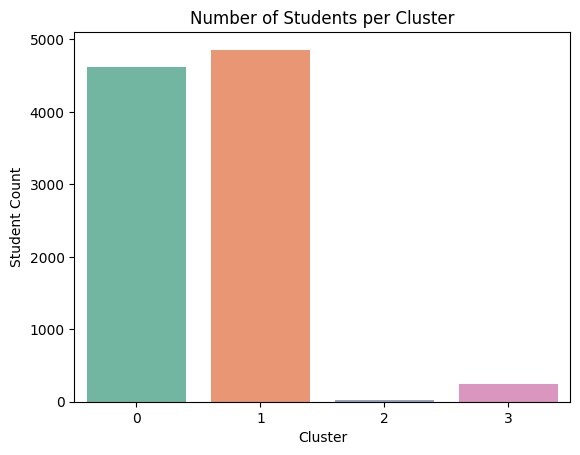

In [42]:
# Cluster sizes
sns.countplot(x="kmeans_cluster", data=student_features, palette="Set2")
plt.title("Number of Students per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Student Count")
plt.show()


C:\Users\missm\AppData\Local\Temp\ipykernel_13508\1971332425.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="kmeans_cluster", y=feat, data=student_features, palette="Set2")


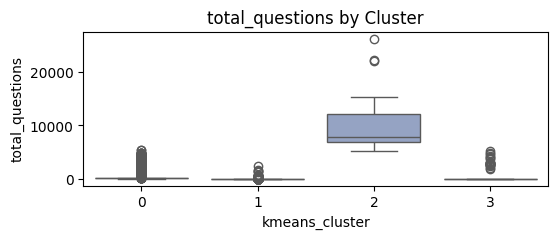

C:\Users\missm\AppData\Local\Temp\ipykernel_13508\1971332425.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="kmeans_cluster", y=feat, data=student_features, palette="Set2")


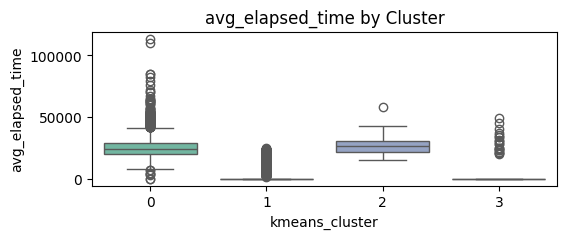

C:\Users\missm\AppData\Local\Temp\ipykernel_13508\1971332425.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="kmeans_cluster", y=feat, data=student_features, palette="Set2")


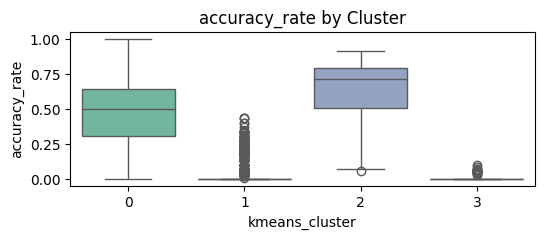

C:\Users\missm\AppData\Local\Temp\ipykernel_13508\1971332425.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="kmeans_cluster", y=feat, data=student_features, palette="Set2")


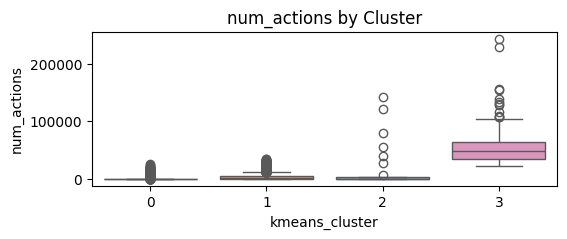

C:\Users\missm\AppData\Local\Temp\ipykernel_13508\1971332425.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="kmeans_cluster", y=feat, data=student_features, palette="Set2")


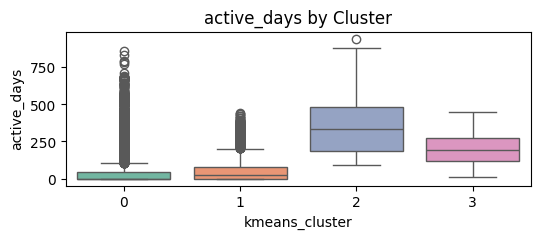

In [43]:
# Boxplots per feature
for feat in ["total_questions","avg_elapsed_time","accuracy_rate","num_actions","active_days"]:
    plt.figure(figsize=(6,2))
    sns.boxplot(x="kmeans_cluster", y=feat, data=student_features, palette="Set2")
    plt.title(f"{feat} by Cluster")
    plt.show()


What to look for: How much overlap is there? Are some clusters tight vs. very spread out?

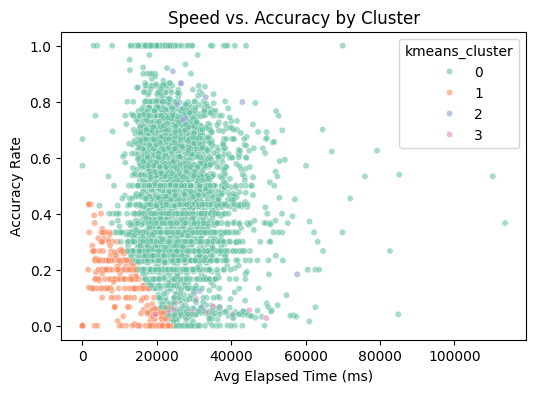

In [44]:
# 2-variable scatterplots/ comparisons of key metircs
plt.figure(figsize=(6,4))
sns.scatterplot(
    x="avg_elapsed_time", y="accuracy_rate",
    hue="kmeans_cluster", palette="Set2",
    data=student_features, alpha=0.6, s=20
)
plt.title("Speed vs. Accuracy by Cluster")
plt.xlabel("Avg Elapsed Time (ms)")
plt.ylabel("Accuracy Rate")
plt.show()


What to look for: Clear separation—fast vs. slow, high vs. low accuracy.



Approximate silhouette (n=2000): 0.488
Calinski–Harabasz (higher=better): 4130
Davies–Bouldin (lower=better):    0.834


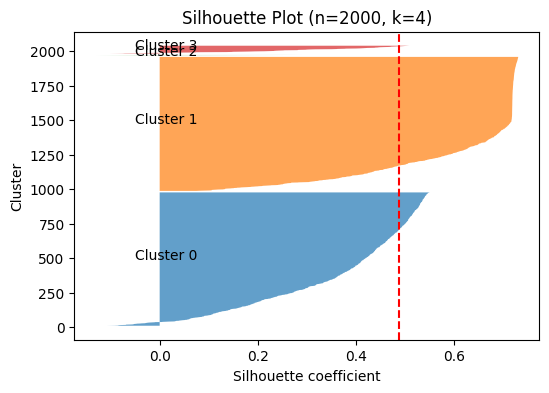

In [51]:
# Silhouette Analysis: Analyze cluster quality
    #Tell you on average whether points lie closer to their own cluster or the next nearest one
    
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    calinski_harabasz_score, davies_bouldin_score
)

# 1) Subsample ~2 000 students at random
n_samp = 2000
idx    = np.random.choice(len(X_scaled), size=n_samp, replace=False)
X_samp = X_scaled[idx]
labels_samp = labels.iloc[idx].values

# 2) Approximate silhouette on the subsample
sil = silhouette_score(X_samp, labels_samp)
print(f"Approximate silhouette (n={n_samp}): {sil:.3f}")

# 3) Full-data cluster‐quality metrics
ch = calinski_harabasz_score(X_scaled, labels)
db = davies_bouldin_score(X_scaled, labels)
print(f"Calinski–Harabasz (higher=better): {ch:.0f}")
print(f"Davies–Bouldin (lower=better):    {db:.3f}")

# 4) (Optional) Silhouette plot on the subsample
sil_vals = silhouette_samples(X_samp, labels_samp)
n_clusters = labels_samp.max() + 1

fig, ax = plt.subplots(figsize=(6,4))
y_lower = 10
for i in range(n_clusters):
    cluster_sil = np.sort(sil_vals[labels_samp == i])
    y_upper = y_lower + len(cluster_sil)
    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0, cluster_sil, alpha=0.7
    )
    ax.text(-0.05, y_lower + 0.5*len(cluster_sil), f"Cluster {i}")
    y_lower = y_upper + 10

ax.axvline(sil, color="red", linestyle="--")
ax.set_xlabel("Silhouette coefficient")
ax.set_ylabel("Cluster")
ax.set_title(f"Silhouette Plot (n={n_samp}, k={n_clusters})")
plt.show()


Average silhouette score (avg_sil)

    Ranges from –1 to +1.

    > 0.5 ⇒ strong, well‐separated clusters

    0.25–0.5 ⇒ reasonable structure, some overlap

    < 0.25 ⇒ weak structure—clusters aren’t very distinct

Each horizontal band is one cluster.

The width at a given height is the silhouette coefficient for a single sample.

Long bars near +1 mean those points sit well within their cluster.

Bars near 0 sit right on the boundary between two clusters.

Negative bars are actually closer to the wrong cluster than their own—those points are mis‐assigned.

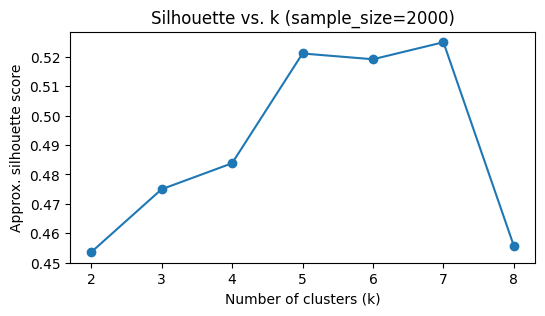

k=8: CH=4735, DB=0.92


In [54]:
# Pick an "optimal" k by silhouette
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Ks = range(2, 9)              # try k = 2 … 8
scores = []

for k in Ks:
    # 1) Fit KMeans on all data
    km = KMeans(n_clusters=k, random_state=42)
    labels_k = km.fit_predict(X_scaled)
    
    # 2) Compute silhouette on a random 2 000‐point subsample
    sil = silhouette_score(
        X_scaled,
        labels_k,
        sample_size=2000,       # pick 2 000 at random for the score
        random_state=42
    )
    scores.append(sil)

# 3) Plot silhouette vs. k
plt.figure(figsize=(6,3))
plt.plot(Ks, scores, "-o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Approx. silhouette score")
plt.title("Silhouette vs. k (sample_size=2000)")
plt.show()



# Compare with full data
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

ch = calinski_harabasz_score(X_scaled, labels_k)
db = davies_bouldin_score(   X_scaled, labels_k)
print(f"k={k}: CH={ch:.0f}, DB={db:.2f}")



Look for the peak

The value of k that gives the highest approximate silhouette is your “most natural” cluster count.

If the peak is at k=4, that confirms your original choice. If it’s at k=3 or 5, you may want to re-run your analysis with that new k.

Check the curve shape

A sharp peak then decline means there’s a clear “right” k.

A flat plateau means several clusterings perform similarly—pick the smallest k in that plateau for simplicity.



Higher CH and lower DB both signal better clusters.


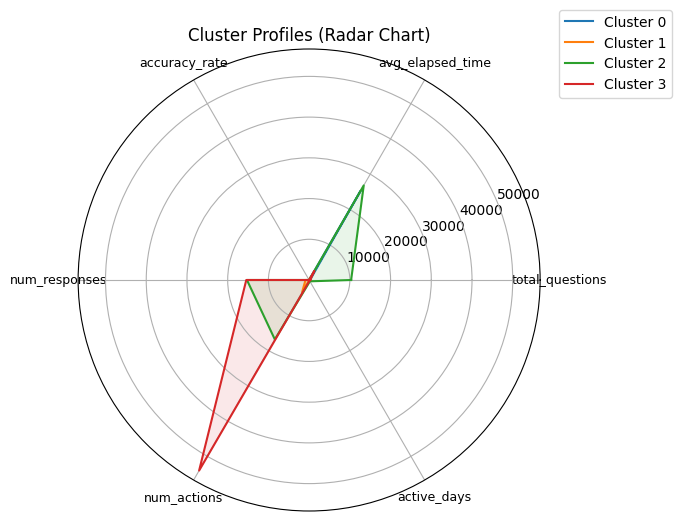

In [46]:
# Radar Chart of Cluster Centroids
    #Visualize each cluster's shape across all 6 features
    
import pandas as pd
import matplotlib.pyplot as plt

# 1) Compute cluster centroid means
centroids = student_features.groupby('kmeans_cluster')[
    ["total_questions","avg_elapsed_time","accuracy_rate",
     "num_responses","num_actions","active_days"]
].mean()

# 2) Prepare for radar plotting
categories = centroids.columns.tolist()
N = len(categories)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the loop

fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))
for idx, row in centroids.iterrows():
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, label=f"Cluster {idx}")
    ax.fill(angles, values, alpha=0.1)
# add category labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=9)
ax.set_title("Cluster Profiles (Radar Chart)")
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.show()


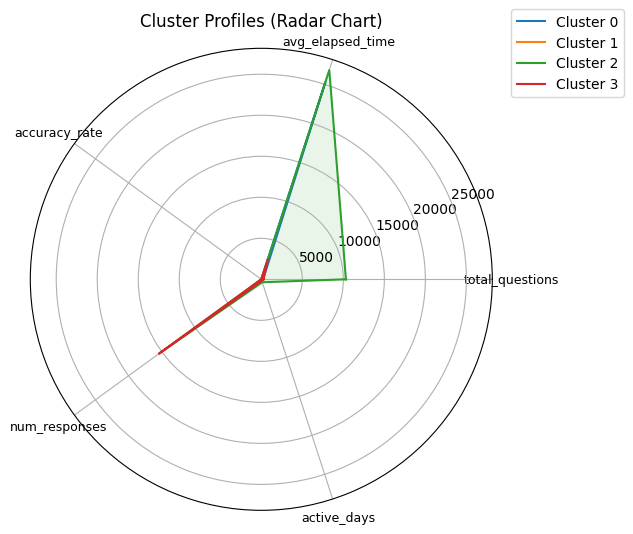

In [49]:
# without num_actions
# Radar Chart of Cluster Centroids
    #Visualize each cluster's shape across all 6 features
    
import pandas as pd
import matplotlib.pyplot as plt

# 1) Compute cluster centroid means
centroids = student_features.groupby('kmeans_cluster')[
    ["total_questions","avg_elapsed_time","accuracy_rate",
     "num_responses","active_days"]
].mean()

# 2) Prepare for radar plotting
categories = centroids.columns.tolist()
N = len(categories)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the loop

fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))
for idx, row in centroids.iterrows():
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, label=f"Cluster {idx}")
    ax.fill(angles, values, alpha=0.1)
# add category labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=9)
ax.set_title("Cluster Profiles (Radar Chart)")
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.show()


Clusters that spike on “active_days” are highly persistent; those dipping on “total_questions” are low‐engagement

Coompare  